# Derivation of the radial velocity field expansion

The derivation connects the symbolic radial-velocity expansion to the Doppler design matrices used by `spectralmap.doppler.DopplerMap`.


In [1]:
from sympy import init_printing

init_printing()

## Line-Profile Response as a Design Matrix

Assume the velocity field is expanded in spherical harmonics:
$$
f(x,y,z)=\sum_{n=1}^{N_y} c_n\,Y_n(x,y,z), \qquad z=\sqrt{1-x^2-y^2}.
$$

At epoch $t$, the observed line profile in velocity bin $v_i$ is
$$
\ell_t(v_i)=\iint_{\mathcal D} W_t(x,y)\,\phi\!\left(v_i-f(x,y,z)\right)\,dx\,dy,
$$
where $W_t$ is the surface weight (brightness, visibility, occultation, projection), and $\phi$ is the local intrinsic line kernel.

Linearizing around reference coefficients $c_0$:
$$
\ell_t(v_i)\approx \ell_t^{(0)}(v_i)+\sum_n D_{ti,n}\,\Delta c_n.
$$

The design matrix is the Jacobian:
$$
D_{ti,n}
=
\left.\frac{\partial \ell_t(v_i)}{\partial c_n}\right|_{c_0}
=
-\iint_{\mathcal D}
W_t(x,y)\,Y_n(x,y,z)\,
\phi'\!\left(v_i-f_0(x,y,z)\right)\,dx\,dy,
$$
with
$$
f_0(x,y,z)=\sum_n c_{0,n}Y_n(x,y,z).
$$

Hence
$$
\Delta \ell \approx D\,\Delta c.
$$

In discrete quadrature:
$$
D_{ti,n}
=
-\sum_{j=1}^{N_s}
w_{tj}\,Y_{jn}\,
\phi'\!\left(v_i-f^{(0)}_{tj}\right),
\qquad
f^{(0)}_{tj}=\sum_n c_{0,n}Y_{jn}.
$$

If polynomial coefficients are $a$ and $c=Ma$, then
$$
D^{(a)} = D^{(c)}\,M.
$$

Small-velocity limit ($f_0\approx 0$):
$$
D_{ti,n}\approx -\phi'(v_i)\iint_{\mathcal D}W_t(x,y)\,Y_n(x,y,z)\,dx\,dy.
$$

In this notebook, we'll derive how to express the radial velocity field of a star at an arbitrary orientation on the sky in terms of spherical harmonics. This allows us to use `starry` to model the Rossiter-McLaughlin waveform **analytically**!

First, let's import some stuff. We'll use `sympy` for the derivations.

In [2]:
import numpy as np
from IPython.display import display, Math
import sympy
from sympy import *
from sympy.functions.special.tensor_functions import KroneckerDelta

print("Using sympy version", sympy.__version__)

# Initialize the session
init_session(quiet=True)

# Define our symbols
x, y, z, mu, nu, l, m, j, k, p, q, n, A, B, C, alpha, omeq = symbols(
    "x y z mu nu l m j k p q n A B C alpha \omega_{eq}"
)

Using sympy version 1.14.0



## The radial velocity field of a star

The polynomial describing the radial component of the velocity field on the projected disk of a star is given by ([Short et al. 2018](https://arxiv.org/abs/1810.09565))

$f(\mathbf{x}, \mathbf{y}, \mathbf{z}) = \omega_{eq}(A\mathbf{x} + B\mathbf{y})(1 - \alpha(-B\mathbf{x} + A\mathbf{y} + C\mathbf{z})^2)$

where 

$A = \sin(i)\cos(\lambda)$

$B = \sin(i)\sin(\lambda)$

$C = \cos(i)$

and $i$ and $\lambda$ are the stellar inclination and obliquity, respectively. The constant $\alpha$ is the shear due to differential rotation. We are assuming a simple linear shear according to the following equation:

$\omega = \omega_{eq}(1 - \alpha \sin^2\theta)$,

where $\omega$ is the angular rotational velocity at a point on the surface, $\omega_{eq}$ is the velocity at the equator, and $\theta$ is the polar angle (latitude).

## Let's expand this function

If we expand all the products in $f$, we can write it as a dot product of a polynomial coefficient vector and the polynomial basis defined in Luger et al. (2018):

In [3]:
def poly_basis(n, x, y):
    """Return the n^th term in the polynomial basis."""
    l = Rational(floor(sqrt(n)))
    m = Rational(n - l * l - l)
    mu = Rational(l - m)
    nu = Rational(l + m)
    if nu % 2 == 0:
        i = Rational(mu, 2)
        j = Rational(nu, 2)
        k = Rational(0)
    else:
        i = Rational(mu - 1, 2)
        j = Rational(nu - 1, 2)
        k = Rational(1)
    return x ** i * y ** j * sqrt(1 - x ** 2 - y ** 2) ** k


# Compute the polynomial basis
basis = Matrix([poly_basis(n, x, y) for n in range(16)]).T

Here's what the polynomial basis looks like (recall that $z = \sqrt{1 - x^2 - y^2}$):

In [4]:
basis

And here's the function we wish to express:

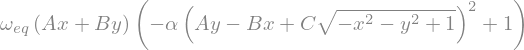

In [5]:
f = (
    omeq
    * (A * x + B * y)
    * (1 - alpha * (-B * x + A * y + C * sqrt(1 - x ** 2 - y ** 2)) ** 2)
)
f

We can use `sympy` to figure out the (exact) representation of `f` in the polynomial basis:

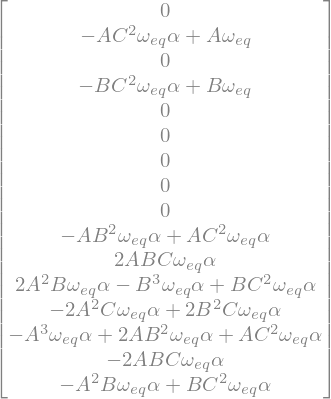

In [6]:
def Coefficient(expression, term):
    """Return the coefficient multiplying `term` in `expression`."""
    # Get the coefficient
    coeff = expression.coeff(term)
    # Set any non-constants in this coefficient to zero. If the coefficient
    # is not a constant, this is not the term we are interested in!
    coeff = coeff.subs(sqrt(1 - x ** 2 - y ** 2), 0).subs(x, 0).subs(y, 0)
    return coeff


vec = Matrix([Coefficient(expand(f), term) for term in basis])
vec

We can check that dotting this vector with the polynomial basis yields the original function $f$:

In [7]:
simplify(factor(basis.dot(vec)) - f) == 0

True

## Now let's represent it in terms of spherical harmonics

Now that we have the vector of polynomial coefficients `vec`, we want to apply a change-of-basis transformation to figure out their (exact) representation in terms of spherical harmonics.

As in Luger et al. (2018), let's compute the change of basis matrix from polynomials to spherical harmonic coefficients. This is the inverse of the $A_1$ matrix introduced in Luger et al. (2018). Note that it includes the normalization of $\frac{2}{\sqrt{\pi}}$ used internally by `starry`.

In [8]:
def SA(l, m):
    """A spherical harmonic normalization constant."""
    return sqrt(
        (2 - KroneckerDelta(m, 0))
        * (2 * l + 1)
        * factorial(l - m)
        / (4 * pi * factorial(l + m))
    )


def SB(l, m, j, k):
    """Another spherical harmonic normalization constant."""
    try:
        ratio = factorial(Rational(l + m + k - 1, 2)) / factorial(
            Rational(-l + m + k - 1, 2)
        )
    except ValueError:
        ratio = 0
    res = (
        2 ** l
        * Rational(
            factorial(m),
            (factorial(j) * factorial(k) * factorial(m - j) * factorial(l - m - k)),
        )
        * ratio
    )
    return simplify(res)


def SC(p, q, k):
    """Return the binomial theorem coefficient `C`."""
    res = factorial(Rational(k, 2)) / (
        factorial(Rational(q, 2))
        * factorial(Rational(k - p, 2))
        * factorial(Rational(p - q, 2))
    )
    return simplify(res)


def Y(l, m, x, y):
    """Return the spherical harmonic of degree `l` and order `m`."""
    res = 0
    z = sqrt(1 - x ** 2 - y ** 2)
    if m >= 0:
        for j in range(0, m + 1, 2):
            for k in range(0, l - m + 1, 2):
                for p in range(0, k + 1, 2):
                    for q in range(0, p + 1, 2):
                        res += (
                            (-1) ** ((j + p) // 2)
                            * SA(l, m)
                            * SB(l, m, j, k)
                            * SC(p, q, k)
                            * x ** (m - j + p - q)
                            * y ** (j + q)
                        )
            for k in range(1, l - m + 1, 2):
                for p in range(0, k, 2):
                    for q in range(0, p + 1, 2):
                        res += (
                            (-1) ** ((j + p) // 2)
                            * SA(l, m)
                            * SB(l, m, j, k)
                            * SC(p, q, k - 1)
                            * x ** (m - j + p - q)
                            * y ** (j + q)
                            * z
                        )
    else:
        for j in range(1, abs(m) + 1, 2):
            for k in range(0, l - abs(m) + 1, 2):
                for p in range(0, k + 1, 2):
                    for q in range(0, p + 1, 2):
                        res += (
                            (-1) ** ((j + p - 1) // 2)
                            * SA(l, abs(m))
                            * SB(l, abs(m), j, k)
                            * SC(p, q, k)
                            * x ** (abs(m) - j + p - q)
                            * y ** (j + q)
                        )
            for k in range(1, l - abs(m) + 1, 2):
                for p in range(0, k, 2):
                    for q in range(0, p + 1, 2):
                        res += (
                            (-1) ** ((j + p - 1) // 2)
                            * SA(l, abs(m))
                            * SB(l, abs(m), j, k)
                            * SC(p, q, k - 1)
                            * x ** (abs(m) - j + p - q)
                            * y ** (j + q)
                            * z
                        )

    return res


def p_Y(l, m, lmax):
    """Return the polynomial basis representation of the spherical harmonic `Y_{lm}`."""
    ylm = Y(l, m, x, y)
    res = [ylm.subs(sqrt(1 - x ** 2 - y ** 2), 0).subs(x, 0).subs(y, 0)]
    for n in range(1, (lmax + 1) ** 2):
        res.append(Coefficient(ylm, poly_basis(n, x, y)))
    return res


def A1(lmax, norm=2 / sqrt(pi)):
    """Return the change of basis matrix A1. The columns of this matrix are given by `p_Y`."""
    res = zeros((lmax + 1) ** 2, (lmax + 1) ** 2)
    n = 0
    for l in range(lmax + 1):
        for m in range(-l, l + 1):
            res[n] = p_Y(l, m, lmax)
            n += 1
    return res * norm

We can now evaluate the change of basis matrix from spherical harmonic coefficients to polynomials, $A_1$ for $l_\mathrm{max} = 3$. We then take the inverse to go from polynomial coeffiecients to $Y_{lm}$ coefficients:

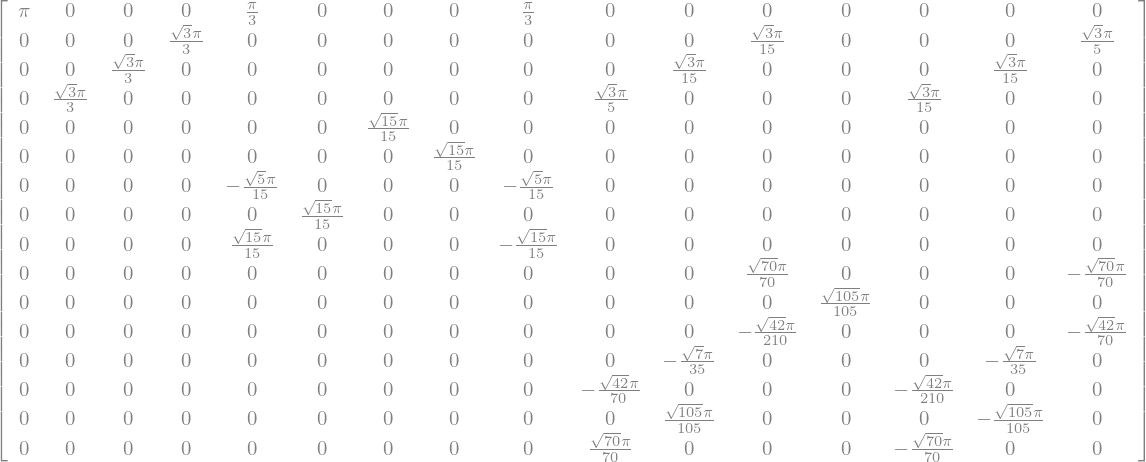

In [9]:
M = Matrix(A1(3)).inv()
M

## The end result

We can finally compute the spherical harmonic coefficients of the function $f$:

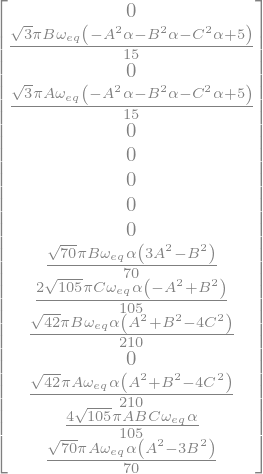

In [10]:
ycoeffs = simplify(M * vec)
ycoeffs

Note that this is the **exact** spherical harmonic representation of the function `f`.

## Interactive visualization

Below you can interactively see how different velocity profiles affect the Rossiter-McLaughlin waveform. We coded up a simple Jupyter widget to visualize the RM effect with `starry`. Try to find the parameters that best fit the measured RV data for the hot jupiter host HD 189733!

In [11]:
# from ipywidgets import interact, interactive, fixed, interact_manual
# import ipywidgets as widgets
# from ipywidgets import Layout
# import matplotlib.pyplot as plt
# import starry

# starry.config.lazy = False
# starry.config.quiet = True

# vslider = widgets.FloatSlider(
#     value=5.0,
#     min=0.1,
#     max=10.0,
#     step=0.01,
#     description=r"$v_\mathrm{eq}$ [km / s]:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".2f",
#     layout=Layout(width="40%"),
# )

# oslider = widgets.FloatSlider(
#     value=-0.50,
#     min=-90,
#     max=90.0,
#     step=0.1,
#     description=r"$\lambda$ [deg]:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".1f",
#     layout=Layout(width="40%"),
# )

# islider = widgets.FloatSlider(
#     value=80,
#     min=1,
#     max=179.0,
#     step=0.1,
#     description=r"$i$ [deg]:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".1f",
#     layout=Layout(width="40%"),
# )

# aslider = widgets.FloatSlider(
#     value=0.65,
#     min=0,
#     max=1.0,
#     step=0.01,
#     description=r"$\alpha$:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".2f",
#     layout=Layout(width="40%"),
# )

# u1slider = widgets.FloatSlider(
#     value=1.50,
#     min=0.0,
#     max=2.0,
#     step=0.01,
#     description=r"$u_1$:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".2f",
#     layout=Layout(width="40%"),
# )

# u2slider = widgets.FloatSlider(
#     value=-0.54,
#     min=-1.0,
#     max=1.0,
#     step=0.01,
#     description=r"$u_2$:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".2f",
#     layout=Layout(width="40%"),
# )

# yslider = widgets.FloatSlider(
#     value=-0.66,
#     min=-1.0,
#     max=1.0,
#     step=0.01,
#     description=r"$b$:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".2f",
#     layout=Layout(width="40%"),
# )

# rslider = widgets.FloatSlider(
#     value=0.158,
#     min=0.01,
#     max=0.5,
#     step=0.001,
#     description=r"$r / R_\star$:",
#     disabled=False,
#     continuous_update=False,
#     orientation="horizontal",
#     readout=True,
#     readout_format=".3f",
#     layout=Layout(width="40%"),
# )


# # RV data for HD 189733 from M. Bedell, corrected for the baseline
# xo_189, rv_189 = np.array(
#     [
#         (-1.610613874961608571e00, -9.981225587125663878e-01),
#         (-1.516819480458127867e00, -9.714511071633751271e-01),
#         (-1.424288949323776032e00, 6.320045379397924989e-01),
#         (-1.327854659861453346e00, 5.854148371854535071e-01),
#         (-1.232414426212717684e00, -1.336544425081228837e00),
#         (-1.135673041276108242e00, 8.028719313260808121e-01),
#         (-1.039663090115350963e00, -7.792463171881536255e-01),
#         (-9.455579835532572641e-01, 1.453737600349995773e00),
#         (-8.467048139722169742e-01, 4.792210501625959296e00),
#         (-7.477458584637551864e-01, 1.599068367822837899e01),
#         (-6.553772659628724906e-01, 2.568976397998631001e01),
#         (-5.591570578315693263e-01, 3.354680499304413388e01),
#         (-4.625798890680289377e-01, 3.502869252636628516e01),
#         (-3.650748292997558764e-01, 3.120010282560906489e01),
#         (-2.704380165973445105e-01, 2.425808674314976088e01),
#         (-1.722747673202078555e-01, 1.747718457640439738e01),
#         (-7.671271240261887114e-02, 7.868697041703853756e00),
#         (1.885820039767528364e-02, -1.486790492997897672e00),
#         (1.155924921815155992e-01, -1.257290268435099279e01),
#         (2.120216221213046814e-01, -2.145286194661639456e01),
#         (3.092993853335966881e-01, -2.891529266112229379e01),
#         (4.068310542953758047e-01, -3.485288236187807343e01),
#         (5.022774536703960013e-01, -3.813336989657727827e01),
#         (5.965030311267133234e-01, -3.469222671746319975e01),
#         (6.955993594669751534e-01, -2.537275959802173020e01),
#         (7.890948706217063569e-01, -1.200930395291834429e01),
#         (8.859815670714117353e-01, -4.065734667423384963e00),
#         (9.792870073717533375e-01, -1.655279022319518845e00),
#         (1.078846540640843621e00, -2.328277573282321100e00),
#         (1.172781349728483358e00, -1.592293655745379510e00),
#         (1.266294524861562687e00, -8.531562584666971816e-01),
#         (1.367439231357534979e00, -7.712511936460941797e-01),
#         (1.658284285150540383e00, -1.439270159869920462e00),
#         (1.761221193029112841e00, -1.678779727093569818e00),
#         (1.853084956802548033e00, -2.067330139152545598e00),
#         (1.948154374912242304e00, -1.369754796494817128e00),
#         (2.037885209964362065e00, 1.118637971248972462e00),
#         (2.137297896820141041e00, -5.354630210913455812e-01),
#         (2.226274259361801011e00, 1.665095065392961260e00),
#         (2.322326451882745779e00, 1.192561909507276141e00),
#     ]
# ).T

# # Create the global starry maps
# map = starry.Map(ydeg=0, udeg=2, rv=True)

# # Force compile some functions
# map.rv()
# map.render()


# def visualize_func(veq=1, inc=90, obl=0, alpha=0, u1=0, u2=0, yo=0, ro=0.1):
#     """Interactive visualization of the RM effect."""
#     # Map resolution for plotting
#     res = 300

#     # Set the map coefficients
#     map[1] = u1
#     map[2] = u2
#     map.inc = inc
#     map.obl = obl
#     map.alpha = alpha
#     map.veq = veq * 1e3

#     # Check if LD is physical
#     if (u1 + u2) > 1 or (u1 + 2 * u2) < 0 or u1 < 0:
#         u1slider.style.handle_color = "#FF0000"
#         u2slider.style.handle_color = "#FF0000"
#     else:
#         u1slider.style.handle_color = "#FFFFFF"
#         u2slider.style.handle_color = "#FFFFFF"

#     # Plot the brightness-weighted velocity field
#     img = map.render(rv=True, res=res) * (np.pi / 1.0e3)
#     fig = plt.figure(figsize=(15, 8))
#     axim = plt.axes((0, 0.05, 0.3, 0.8))
#     axcb = plt.axes((0, 0.85, 0.3, 0.03))
#     axrm = plt.axes((0.4, 0.20, 0.6, 0.5))
#     im = axim.imshow(
#         img, cmap="RdBu_r", origin="lower", vmin=-veq, vmax=veq, extent=(-1, 1, -1, 1)
#     )
#     cb = plt.colorbar(im, orientation="horizontal", cax=axcb)
#     cb.ax.set_xlabel("Radial velocity [km / s]")
#     axim.contour(
#         img,
#         origin="lower",
#         levels=np.linspace(-veq, veq, 20),
#         colors=["k" for i in range(20)],
#         alpha=0.25,
#         extent=(-1, 1, -1, 1),
#     )
#     axim.axis("off")
#     axim.set_aspect(1)
#     axim.axhline(yo, color="k", alpha=0.5)
#     axim.axhline(yo + 0.5 * ro, color="k", ls="--", alpha=0.5)
#     axim.axhline(yo - 0.5 * ro, color="k", ls="--", alpha=0.5)

#     # Compute the RM effect amplitude
#     xo = np.linspace(-1 - 2 * ro, 1 + 2 * ro, 1000)
#     RM = map.rv(xo=xo, yo=yo, ro=ro)

#     # Plot it
#     axrm.plot(xo, RM)
#     axrm.set_xlabel(r"Occultor x position [$R_\star$]", fontsize=16)
#     axrm.set_ylabel("Radial velocity [m /s]", fontsize=16)
#     axrm.set_title("The Rossiter-McLaughlin effect", fontsize=20)
#     axrm.plot(xo_189, rv_189, ".")


# def visualize():
#     return interact(
#         visualize_func,
#         veq=vslider,
#         inc=islider,
#         obl=oslider,
#         alpha=aslider,
#         u1=u1slider,
#         u2=u2slider,
#         yo=yslider,
#         ro=rslider,
#     )


# visualize();

## One possible solution

The following values should get you a pretty good fit. They are close to the means of the posterior distributions when we do a full MCMC fit of the dataset, but they are probably not the "true" values.

| Parameter | Value |
| --- | --- |
| $v_{eq}$  | 5.00  |
|$\lambda$  | -0.50 |
|$i$        | 80.0  |
|$\alpha$   | 0.65  |
|$u_1$      | 1.50  |
|$u_2$      | -0.54 |
|$b$        | -0.66 |
|$r/R_\star$|  0.158|

## Line-profile response to differential rotation

This section demonstrates a direct numerical experiment:

1. Build a 2D Cartesian grid on the visible stellar disk.
2. Assume a known surface intensity with linear limb darkening.
3. Assume a narrow Gaussian local line profile in velocity space.
4. Integrate over the disk to obtain the observed line profile.
5. Vary the differential-rotation parameter $\alpha$.
6. Differentiate numerically with respect to $\alpha$ and test linearity/nonlinearity.

We use the same projected velocity-field form as above,
$$
v(x,y,z;\alpha)=v_{\mathrm{eq}}(Ax+By)\left[1-\alpha(-Bx+Ay+Cz)^2\right],
$$
with $A=\sin i\cos\lambda$, $B=\sin i\sin\lambda$, and $C=\cos i$.

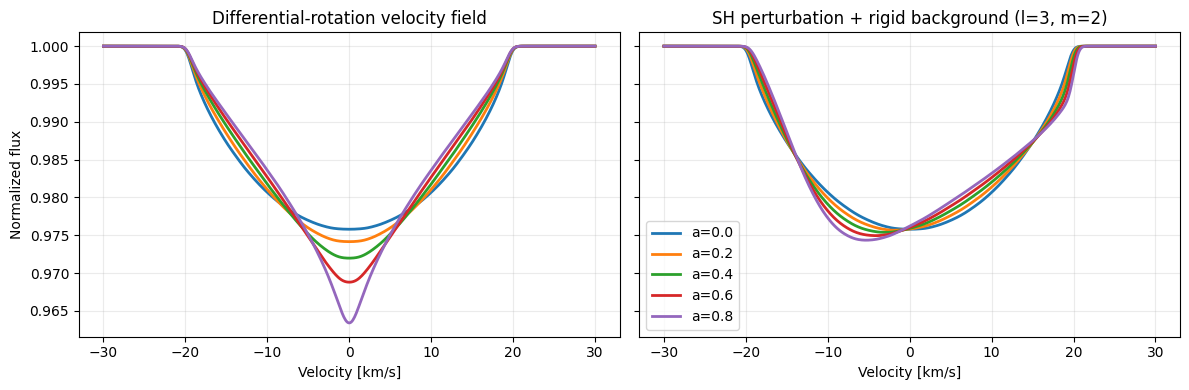

Disk points: 37644


In [15]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm


def make_disk_grid(n_side=220):
    """Uniform Cartesian grid on the visible disk."""
    x1 = np.linspace(-1.0, 1.0, n_side)
    y1 = np.linspace(-1.0, 1.0, n_side)
    dx = x1[1] - x1[0]
    dy = y1[1] - y1[0]
    xx, yy = np.meshgrid(x1, y1)
    mask = (xx**2 + yy**2) <= 1.0

    x = xx[mask]
    y = yy[mask]
    z = np.sqrt(1.0 - x**2 - y**2)
    w = dx * dy * np.ones_like(x)
    return x, y, z, w


def rigid_rotation_velocity(x, y, veq=20.0, inc_deg=80.0, obl_deg=-0.5):
    """Projected rigid-rotation background velocity in km/s."""
    inc = np.deg2rad(inc_deg)
    obl = np.deg2rad(obl_deg)
    A = np.sin(inc) * np.cos(obl)
    B = np.sin(inc) * np.sin(obl)
    return veq * (A * x + B * y)


def velocity_field(alpha, x, y, z, veq=20, inc_deg=80.0, obl_deg=-0.5):
    """Projected differential-rotation field in km/s."""
    inc = np.deg2rad(inc_deg)
    obl = np.deg2rad(obl_deg)
    A = np.sin(inc) * np.cos(obl)
    B = np.sin(inc) * np.sin(obl)
    C = np.cos(inc)
    v_bg = rigid_rotation_velocity(x, y, veq=veq, inc_deg=inc_deg, obl_deg=obl_deg)
    return v_bg * (1.0 - alpha * (-B * x + A * y + C * z) ** 2)


def real_spherical_harmonic(l, m, x, y, z):
    """Real-valued spherical harmonic Y_lm on the visible hemisphere."""
    phi = np.mod(np.arctan2(y, x), 2.0 * np.pi)
    theta = np.arccos(np.clip(z, -1.0, 1.0))

    if m > 0:
        ylm = np.sqrt(2.0) * (-1) ** m * np.real(sph_harm(m, l, phi, theta))
    elif m < 0:
        ylm = np.sqrt(2.0) * (-1) ** m * np.imag(sph_harm(-m, l, phi, theta))
    else:
        ylm = np.real(sph_harm(0, l, phi, theta))

    return ylm


def velocity_field_ylm(
    alpha,
    x,
    y,
    z,
    l=3,
    m=2,
    background_veq=20.0,
    inc_deg=80.0,
    obl_deg=-0.5,
    zero_mean=True,
):
    """SH perturbation on top of rigid background: v = v_bg + alpha * Y_lm."""
    ylm = real_spherical_harmonic(l, m, x, y, z)
    if zero_mean:
        ylm = ylm - np.mean(ylm)

    rms = np.sqrt(np.mean(ylm**2))
    if rms > 0:
        ylm = ylm / rms

    v_bg = rigid_rotation_velocity(x, y, veq=background_veq, inc_deg=inc_deg, obl_deg=obl_deg)
    return v_bg + alpha * ylm


def local_gaussian_line(v, sigma=0.5, depth=0.55):
    """Continuum-normalized Gaussian absorption profile in velocity space."""
    return 1.0 - depth * np.exp(-0.5 * (v / sigma) ** 2)


def observed_profile(alpha, v_grid, x, y, z, w, u1=0.6, velocity_fn=velocity_field, **vel_kwargs):
    """Disk-integrated observed line profile F(v; alpha)."""
    mu = z
    I_cont = 1.0 - u1 * (1.0 - mu)
    v_pix = velocity_fn(alpha, x, y, z, **vel_kwargs)

    F = np.zeros_like(v_grid)
    for vp, wp in zip(v_pix, w * I_cont):
        F += wp * local_gaussian_line(v_grid - vp)

    # Normalize by continuum flux so the continuum level is near unity.
    F /= np.sum(w * I_cont)
    return F


# Build disk quadrature and velocity axis.
xg, yg, zg, wg = make_disk_grid(n_side=220)
v_axis = np.linspace(-30.0, 30.0, 600)

# Show line profiles as alpha varies for both velocity-field families.
alpha_vals = [0.0, 0.2, 0.4, 0.6, 0.8]
profiles_diffrot = {
    a: observed_profile(a, v_axis, xg, yg, zg, wg, veq=20.0, inc_deg=80.0, obl_deg=-0.5)
    for a in alpha_vals
}

l_demo, m_demo = 3, 2
profiles_ylm = {
    a: observed_profile(
        a,
        v_axis,
        xg,
        yg,
        zg,
        wg,
        velocity_fn=velocity_field_ylm,
        l=l_demo,
        m=m_demo,
        background_veq=20.0,
        inc_deg=80.0,
        obl_deg=-0.5,
        zero_mean=True,
    )
    for a in alpha_vals
}

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for a in alpha_vals:
    ax[0].plot(v_axis, profiles_diffrot[a], lw=2, label=f"a={a:.1f}")
    ax[1].plot(v_axis, profiles_ylm[a], lw=2, label=f"a={a:.1f}")

ax[0].set_title("Differential-rotation velocity field")
ax[1].set_title(f"SH perturbation + rigid background (l={l_demo}, m={m_demo})")
for axy in ax:
    axy.set_xlabel("Velocity [km/s]")
    axy.grid(alpha=0.25)
ax[0].set_ylabel("Normalized flux")
ax[1].legend(loc="best")
plt.tight_layout()
plt.show()

print(f"Disk points: {xg.size}")

Mode: diffrot
Estimated nonlinearity power p from ||residual|| ~ |delta|^p: 2.00


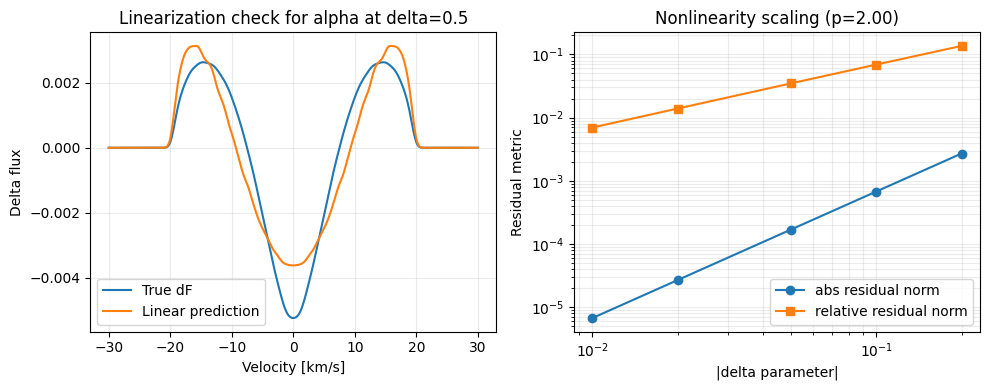

In [21]:
model = "diffrot"  # choose from: "diffrot", "ylm"

alpha0 = 0.0
h = 1e-3
veq = 20.0

if model == "diffrot":
    velocity_fn = velocity_field
    vel_kwargs = dict(veq=veq, inc_deg=80.0, obl_deg=-0.5)
    strength_label = "alpha"
elif model == "ylm":
    l_test, m_test = 3, 2
    velocity_fn = velocity_field_ylm
    vel_kwargs = dict(
        l=l_test,
        m=m_test,
        background_veq=veq,
        inc_deg=80.0,
        obl_deg=-0.5,
        zero_mean=True,
    )
    strength_label = f"a_lm for (l={l_test}, m={m_test})"
else:
    raise ValueError("model must be 'diffrot' or 'ylm'")

F0 = observed_profile(alpha0, v_axis, xg, yg, zg, wg, velocity_fn=velocity_fn, **vel_kwargs)
Fp = observed_profile(alpha0 + h, v_axis, xg, yg, zg, wg, velocity_fn=velocity_fn, **vel_kwargs)
Fm = observed_profile(alpha0 - h, v_axis, xg, yg, zg, wg, velocity_fn=velocity_fn, **vel_kwargs)

# Numerical linear response wrt control parameter.
dF_dalpha = (Fp - Fm) / (2.0 * h)

# Nonlinearity test across perturbation sizes.
delta_alpha = np.array([0.01, 0.02, 0.05, 0.10, 0.20])
abs_resid = []
rel_resid = []

for da in delta_alpha:
    F_true = observed_profile(alpha0 + da, v_axis, xg, yg, zg, wg, velocity_fn=velocity_fn, **vel_kwargs)
    dF_true = F_true - F0
    dF_lin = dF_dalpha * da
    resid = dF_true - dF_lin

    abs_resid.append(np.linalg.norm(resid))
    rel_resid.append(np.linalg.norm(resid) / np.linalg.norm(dF_true))

abs_resid = np.array(abs_resid)
rel_resid = np.array(rel_resid)

# Expected: absolute residual scales roughly as O((delta parameter)^2).
p = np.polyfit(np.log(delta_alpha), np.log(abs_resid), 1)[0]
print(f"Mode: {model}")
print(f"Estimated nonlinearity power p from ||residual|| ~ |delta|^p: {p:.2f}")

# Compare true and linearized response for one representative step.
da_show = 0.5
F_show = observed_profile(alpha0 + da_show, v_axis, xg, yg, zg, wg, velocity_fn=velocity_fn, **vel_kwargs)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(v_axis, F_show - F0, label="True dF")
plt.plot(v_axis, dF_dalpha * da_show, "-", label="Linear prediction")
plt.xlabel("Velocity [km/s]")
plt.ylabel("Delta flux")
plt.title(f"Linearization check for {strength_label} at delta={da_show}")
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(1, 2, 2)
plt.loglog(delta_alpha, abs_resid, "o-", label="abs residual norm")
plt.loglog(delta_alpha, rel_resid, "s-", label="relative residual norm")
plt.xlabel("|delta parameter|")
plt.ylabel("Residual metric")
plt.title(f"Nonlinearity scaling (p={p:.2f})")
plt.legend()
plt.grid(alpha=0.25, which="both")
plt.tight_layout()
plt.show()